In [14]:
import os, random, json, warnings
import pandas as pd
DATA_DIR = "."
path = os.path.join(DATA_DIR, "featured_v0.parquet")
df= pd.read_parquet(path)

In [15]:
df['is_holiday'].value_counts()


is_holiday
0.0    7648
Name: count, dtype: int64

In [16]:
df[df['is_holiday'] == 1]


,message_id,campaign_id,client_id,date,sent_at,is_opened,opened_first_time_at,opened_last_time_at,is_clicked,clicked_first_time_at,...,total_messages,total_campaigns,total_purchases,avg_time_since_first_purchase,avg_time_since_last_open,avg_time_since_last_click,avg_time_since_unsubscribe,avg_time_since_complaint,campaign_duration,avg_campaign_duration


In [3]:
import os, random, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Tensorflow 관련 제거하고 Scikit-Learn RandomForest 추가
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models, optimizers, callbacks

# Optuna
import optuna
from optuna.integration import TFKerasPruningCallback
from sklearn.model_selection import StratifiedKFold
import gc
import xgboost as xgb
# =========================
# CONFIG
# =========================
SEED = 1
MODE = "STRICT_CAUSAL"
SPLIT_STRATEGY = "RANDOM_ROW"
POS_RATIO = 0.10
TARGET_TOTAL = 100_000

EPOCHS = 50           # 최종 재학습 epoch
VAL_FRAC = 0.15
TEST_FRAC = 0.15
TIME_HOLDOUT_TEST_WEEKS = 8
TOL = 0.0025

# ✅ Optuna(튜닝) 전용 설정
N_TRIALS = 10             # Optuna trial 수
EPOCHS_TUNE = 15         # 튜닝용 epoch (CV 안에서)
MAX_TUNE_SAMPLES = 30_000  # fold별 train에서 최대 이만큼만 사용

# 최종 평가용 threshold
OPERATING_THR = 0.5
DATA_DIR = "."
# 고정 시드
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED);
rng = np.random.RandomState(SEED)
path_v0 = os.path.join(DATA_DIR, "featured_all.parquet")
final_data = pd.read_parquet(path_v0)

print(f"\n[FINAL DATA] Total Shape: {final_data.shape}")
print("========================================")

# =========================
# 수동 metric + AUC 계산 함수
# =========================
def compute_roc_auc_manual(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)

    # NaN 제거
    mask = ~np.isnan(y_prob)
    y_true = y_true[mask]
    y_prob = y_prob[mask]

    n_pos = (y_true == 1).sum()
    n_neg = (y_true == 0).sum()
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    # 확률 내림차순 정렬
    order = np.argsort(-y_prob)
    y_true_sorted = y_true[order]

    cum_pos = np.cumsum(y_true_sorted == 1)
    cum_neg = np.cumsum(y_true_sorted == 0)

    tpr = cum_pos / n_pos
    fpr = cum_neg / n_neg

    # 사다리꼴 적분
    auc = 0.0
    prev_fpr = 0.0
    prev_tpr = 0.0
    for i in range(len(y_true_sorted)):
        auc += (fpr[i] - prev_fpr) * (tpr[i] + prev_tpr) / 2.0
        prev_fpr = fpr[i]
        prev_tpr = tpr[i]

    return float(auc)


# =========================
# 수동 metric + AUC + AIC/BIC 계산 함수
# =========================
def compute_aic_bic_manual(y_true, y_prob, n_features):
    """
    Log-Likelihood를 기반으로 AIC, BIC 계산
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    
    # Log(0) 방지를 위한 clipping (epsilon)
    eps = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)
    
    # Log Likelihood 계산
    # L = sum( y*log(p) + (1-y)*log(1-p) )
    log_likelihood = np.sum(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    
    n = len(y_true)
    k = n_features
    
    aic = 2 * k - 2 * log_likelihood
    bic = k * np.log(n) - 2 * log_likelihood
    
    return float(aic), float(bic), float(log_likelihood)

def compute_classification_metrics(y_true, y_prob, thr=0.8, n_features=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= thr).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    n = len(y_true)
    eps = 1e-9

    accuracy    = (tp + tn) / (n + eps)
    precision   = tp / (tp + fp + eps)
    recall      = tp / (tp + fn + eps)
    specificity = tn / (tn + fp + eps)
    f1          = 2 * precision * recall / (precision + recall + eps)

    roc_auc = compute_roc_auc_manual(y_true, y_prob)

    metrics = {
        "accuracy":       float(accuracy),
        "precision":      float(precision),
        "recall":         float(recall),
        "specificity":    float(specificity),
        "f1":             float(f1),
        "roc_auc":        float(roc_auc),
        "n_eval":         int(n),
        "pos_rate_eval":  float(y_true.mean()),
    }

    # [추가됨] n_features가 들어오면 AIC/BIC 계산
    if n_features is not None:
        aic, bic, ll = compute_aic_bic_manual(y_true, y_prob, n_features)
        metrics["aic"] = aic
        metrics["bic"] = bic
        metrics["log_likelihood"] = ll
        metrics["n_features"] = int(n_features)

    cm = (tn, fp, fn, tp)
    return metrics, cm


# =========================
# SPLIT
# =========================
def brief(name, df):
    if df is None or len(df) == 0:
        print(f"[{name}] n=0"); return
    pos = int(df["is_purchased"].sum())
    n = len(df); rate = pos / max(n, 1)
    print(f"[{name}] n={n:,}  pos={pos:,}  rate={rate:.6f}")
def brief(name, df):
    if df is None or len(df) == 0:
        print(f"[{name}] n=0"); return
    pos = int(df["is_purchased"].sum())
    n = len(df); rate = pos / max(n, 1)
    print(f"[{name}] n={n:,}  pos={pos:,}  rate={rate:.6f}")

def check_ratio(df, target_ratio=0.10, tol=TOL, name="dataset"):
    if len(df) == 0: return
    r = float(df["is_purchased"].mean())
    ok = abs(r - target_ratio) <= tol
    print(f"[check {name}] pos_rate={r:.6f}  target={target_ratio:.2f}  diff={r-target_ratio:+.6f}  {'OK' if ok else 'WARN'}")

def stratified_fixed_sample(df, target_col="is_purchased", total_n=100_000, pos_ratio=0.10, seed=SEED):
    n_pos_k = int(round(total_n * pos_ratio))
    n_neg_k = total_n - n_pos_k
    pos = df[df[target_col] == 1]
    neg = df[df[target_col] == 0]
    pos_s = pos.sample(n=min(n_pos_k, len(pos)), random_state=seed, replace=False)
    neg_s = neg.sample(n=min(n_neg_k, len(neg)), random_state=seed, replace=False)
    out = pd.concat([pos_s, neg_s], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

def split_random_row_simple(df, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=SEED):
    rng_local = np.random.RandomState(seed)
    N = len(df)
    idx = np.arange(N); rng_local.shuffle(idx)
    n_test = int(round(N * test_frac))
    n_val  = int(round(N * val_frac))
    te_idx = idx[:n_test]
    va_idx = idx[n_test:n_test+n_val]
    tr_idx = idx[n_test+n_val:]
    te = df.iloc[te_idx].reset_index(drop=True)
    va = df.iloc[va_idx].reset_index(drop=True)
    tr = df.iloc[tr_idx].reset_index(drop=True)
    return tr, va, te

dataset = final_data.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
brief("dataset(raw)", dataset)
if TARGET_TOTAL and len(dataset) > TARGET_TOTAL:
    dataset = stratified_fixed_sample(dataset, target_col="is_purchased",
                                      total_n=TARGET_TOTAL, pos_ratio=POS_RATIO, seed=SEED)
brief("dataset(after 100K sampling)", dataset)
check_ratio(dataset, POS_RATIO, name="dataset(100K)")

if SPLIT_STRATEGY == "RANDOM_ROW":
    train_df, val_df, test_df = split_random_row_simple(dataset)
elif SPLIT_STRATEGY == "TIME_HOLDOUT":
    train_df, val_df, test_df = split_time_holdout(dataset)
else:
    train_df, val_df, test_df = split_user_disjoint(dataset)
    
TARGET = "is_purchased"

# =======================================================
# 1. Base Features (v0) - 총 41개
# : 캠페인, 채널, 플랫폼, 기본 이력 통계 등 가장 기초적인 정보
# =======================================================
cols_v0 = [
    'avg_campaign_duration', 'avg_time_since_complaint', 'avg_time_since_first_purchase',
    'avg_time_since_last_click', 'avg_time_since_last_open', 'avg_time_since_unsubscribe',
    'camp_campaign_typebulk', 'camp_campaign_typetransactional', 'camp_campaign_typetrigger',
    'camp_channelemail', 'camp_channelmobile_push', 'camp_channelmultichannel', 'camp_channelsms',
    'camp_topicevent', 'camp_topichappy.birthday', 'camp_topicleave.review',
    'camp_topicoffer.after.purchase', 'camp_topicother', 'camp_topicsale.out',
    'channel_email', 'channel_mobile_push', 'channel_web_push',
    'email_provider_gmail.com', 'email_provider_mail.ru', 'email_provider_other',
    'is_holiday',
    'message_type_bulk', 'message_type_transactional', 'message_type_trigger',
    'platform.', 'platform.desktop', 'platform.phablet', 'platform.smartphone', 'platform.tablet',
    'prev_is_clicked', 'prev_is_complained', 'prev_is_opened', 'prev_is_unsubscribed',
    'total_campaigns', 'total_messages', 'total_purchases'
]

# =======================================================
# 2. Add-on Features (v1) - 총 3개
# : 구매 주기 및 행동 위험도 (Hazard/Refraction)
# =======================================================
cols_v1 = [
    'days_since_last_purchase',
    'feat_rtb_hazard',
    'feat_postbuy_refrac'
]

# =======================================================
# 3. Add-on Features (v2) - 총 6개
# : 캘린더 효과(주말/월초) 및 시간대 이동(Shift)
# =======================================================
cols_v2 = [
    'cal_is_weekend',
    'cal_week_of_month',
    'feat_dow_shift',
    'feat_eoq_bump',
    'feat_hour_shift',
    'feat_payday_bump'
]

# =======================================================
# 4. Add-on Features (v3) - 총 9개
# : 유저 피로도(Fatigue) 및 최근 30일 반응률(Context)
# =======================================================
cols_v3 = [
    'ctx_tc_open_rate_30d',
    'feat_fatigue',
    'feat_last_any_hours',
    'feat_last_email_hours',
    'feat_last_mobile_push_hours',
    'u_cadence_std_30d',
    'u_click_rate_30d',
    'u_open_cnt_30d',
    'u_open_rate_30d'
]

# =======================================================
# 5. Add-on Features (v4) - 총 5개
# : 토픽 신선도 및 행동 경로 유사성 (Sequence/Path)
# =======================================================
cols_v4 = [
    'feat_like_last_success',
    'feat_path_align',
    'feat_topic_novelty',
    'topic_N7',
    'topic_t_since_hours'
]
final_data["feat_postbuy_refrac"] = 1 - final_data["feat_postbuy_refrac"]


def get_feat_cols(df):
    """
    데이터프레임에서 학습에 사용할 최종 수치형 변수 리스트를 반환합니다.
    Target과 제외 리스트(ID, Leakage, Collinear)를 필터링합니다.
    """
    # 1. 모든 수치형 컬럼 추출
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # 2. 제외 대상 필터링 (Target + Drop List)
    final_cols = list(cols_v0 + cols_v1 + cols_v2 + cols_v3 + cols_v4)
    
    # 3. 정렬 (모델 재현성을 위해 이름순 정렬)
    return sorted(final_cols)

# -------------------------------------------------------
# 실행 및 결과 확인
# -------------------------------------------------------
# train_df는 이미 로드되어 있다고 가정
feat_cols = get_feat_cols(train_df)
n_feat = len(feat_cols)

def prepare_data_2d(df, feature_columns):
    X = df[feature_columns].fillna(0).astype(np.float32).values
    Y = df[TARGET].fillna(0).astype(np.int32).values
    return X, Y

Xtr, Ytr = prepare_data_2d(train_df, feat_cols)
Xva, Yva = prepare_data_2d(val_df, feat_cols)
Xte, Yte = prepare_data_2d(test_df, feat_cols)

print("=== Data Shapes for XGBoost ===")
print(f"Train: X={Xtr.shape}, Y={Ytr.shape}")
print(f"Val  : X={Xva.shape}, Y={Yva.shape}")
print(f"Test : X={Xte.shape}, Y={Yte.shape}")

# =========================
# MODEL BUILD & TRAINING (Fixed Params)
# =========================
print("\n[Final] Retraining XGBoost model on full Train set with best hyperparameters...")
best_params_xgb = {
      "n_estimators": 450,
      "learning_rate": 0.0608598829841135,
      "max_depth": 3,
      "min_child_weight": 4,
      "subsample": 0.5733779454085566,
      "colsample_bytree": 0.5461692973843989,
      "gamma": 0.9313010568883545,
      "reg_alpha": 0.0011840345146135153,
      "reg_lambda": 0.00240217612024316,
      "objective": "binary:logistic",
      "eval_metric": "auc",
      "booster": "gbtree",
      "tree_method": "hist",
      "device": "cuda",
      "random_state": 1,
      "n_jobs": -1
    }

best_params_xgb.update({
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'booster': 'gbtree',
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': SEED,
    'n_jobs': -1,
})

# 최종 모델은 전체 Xtr로 학습, Xva를 Early Stopping 검증용으로 사용
final_xgb = xgb.XGBClassifier(**best_params_xgb, early_stopping_rounds=50)

final_xgb.fit(
    Xtr, Ytr,
    eval_set=[(Xva, Yva)],
    verbose=False
)

# =========================
# FINAL EVALUATION
# =========================
y_prob = final_xgb.predict_proba(Xte)[:, 1]
y_true = Yte

# [수정] 사용된 피처 개수 추출 (XGBoost 입력 데이터의 컬럼 수)
n_features_used = Xte.shape[1]

# [수정] n_features 인자 추가
final_metrics, (tn, fp, fn, tp) = compute_classification_metrics(
    y_true, y_prob, 
    thr=OPERATING_THR,
    n_features=n_features_used  # ★ 이 부분을 추가
)

final_metrics.update({
    "mode": MODE,
    "split": SPLIT_STRATEGY,
    # "best_params_xgb": best_params_xgb  # (옵션) 파라미터 저장
})

print(json.dumps({"metrics": final_metrics}, indent=2))
print("confusion_matrix [tn fp fn tp]:", tn, fp, fn, tp)

2026-04-22 18:43:55.159277: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 18:43:55.317246: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776851035.380511   36272 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776851035.395793   36272 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776851035.518423   36272 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 


[FINAL DATA] Total Shape: (433520, 124)
[dataset(raw)] n=433,520  pos=43,352  rate=0.100000
[dataset(after 100K sampling)] n=100,000  pos=10,000  rate=0.100000
[check dataset(100K)] pos_rate=0.100000  target=0.10  diff=+0.000000  OK
=== Data Shapes for XGBoost ===
Train: X=(70000, 64), Y=(70000,)
Val  : X=(15000, 64), Y=(15000,)
Test : X=(15000, 64), Y=(15000,)

[Final] Retraining XGBoost model on full Train set with best hyperparameters...
{
  "metrics": {
    "accuracy": 0.9808666666666013,
    "precision": 0.962769918093103,
    "recall": 0.8450980392151339,
    "specificity": 0.9962880475129179,
    "f1": 0.900104419967903,
    "roc_auc": 0.9921535147095484,
    "n_eval": 15000,
    "pos_rate_eval": 0.102,
    "aic": 1761.9097254668704,
    "bic": 2249.3212761922687,
    "log_likelihood": -816.9548627334352,
    "n_features": 64,
    "mode": "STRICT_CAUSAL",
    "split": "RANDOM_ROW"
  }
}
confusion_matrix [tn fp fn tp]: 13420 50 237 1293


In [4]:
# =====================================================
# SHAP (XGBoost) : 한글 summary plot + 중요도 테이블(+방향성)
# - 그래프 순서 == 테이블 순서 보장
# - 방향성은 corr 대신 "high-low mean SHAP" (그래프의 빨강/파랑 좌우와 가장 일치)
# =====================================================

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import platform
import matplotlib.font_manager as fm

# -------------------------------------------------------
# 0) (필수) 입력 준비: 아래 4개는 네 환경에 이미 있어야 함
#   - final_xgb : 학습된 XGBClassifier / xgboost model
#   - Xtr, Xte  : train/test feature (DataFrame 권장)
#   - feat_cols : 모델 학습에 사용한 feature 컬럼 리스트 (순서 매우 중요!)
#   - kor_col_map_updated : 영어컬럼 -> 한글명 매핑 dict
# -------------------------------------------------------

# -------------------------------------------------------
# 1) 한글 폰트 설정
# -------------------------------------------------------
system_name = platform.system()
if system_name == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
elif system_name == 'Windows':  # Windows
    font_list = [f.name for f in fm.fontManager.ttflist]
    if 'NanumMyeongjo Eco' in font_list:
        plt.rcParams['font.family'] = 'NanumMyeongjo Eco'
    else:
        plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumMyeongjo Eco'

plt.rcParams['axes.unicode_minus'] = False

# 변수명 매핑 딕셔너리 정의
kor_col_map_updated = {
    "is_purchased": "구매 여부(Target)",
    
    # [기존 매핑]
    "days_since_last_purchase": "마지막 구매 경과일",
    "feat_rtb_hazard": "재구매 준비도",
    "feat_postbuy_refrac": "구매 후 불응기",
    "feat_hour_shift": "선호 시간대 일치도",
    "feat_dow_shift": "선호 요일 일치도",
    "cal_is_weekend": "주말 여부",
    "cal_week_of_month": "주차 정보",
    "feat_payday_bump": "급여일 근접도",
    "feat_eoq_bump": "분기 말 근접도",
    "feat_fatigue": "마케팅 피로도",
    "feat_last_email_hours": "이메일 경과 시간",
    "feat_last_mobile_push_hours": "푸시 경과 시간",
    "feat_last_any_hours": "마지막 접촉 경과 시간",
    "u_cadence_std_30d": "발송 간격 표준편차",
    "u_open_rate_30d": "유저 오픈율(30일 내)",
    "u_click_rate_30d": "유저 클릭율(30일 내)",
    "u_open_cnt_30d": "유저 오픈 횟수(30일 내)",
    "feat_topic_novelty": "주제 신선도",
    "topic_N7": "주제 노출 수(7일)",
    "topic_t_since_hours": "주제 경과 시간",
    "feat_path_align": "성공 경로 일치도",
    "feat_like_last_success": "성공 캠페인 유사도",
    "ctx_tc_open_rate_30d": "채널별 특정 주제 캠페인 오픈율(30일 내)",

    # [추가된 베이스라인 매핑 - '[베이스라인]' 태그 제거됨]
    "avg_campaign_duration": "캠페인 지속 시간(평균)",
    "avg_time_since_complaint": "불만 접수 경과 시간(평균)",
    "avg_time_since_first_purchase": "가입 기간(첫 구매 경과)",
    "avg_time_since_last_click": "마지막 클릭 경과 시간(평균)",
    "avg_time_since_last_open": "마지막 오픈 경과 시간(평균)",
    "avg_time_since_unsubscribe": "구독 취소 경과 시간(평균)",
    "is_holiday": "공휴일 여부",
    "total_campaigns": "총 캠페인 수",
    "total_messages": "총 메시지 수신 수",
    "total_purchases": "총 구매 횟수",
    "platform.": "메시지 수신: 기타",
    "platform.desktop": "메시지 수신: 데스크탑",
    "platform.phablet": "메시지 수신: 패블릿",
    "platform.smartphone": "메시지 수신: 스마트폰",
    "platform.tablet": "메시지 수신: 태블릿",
    "channel_email": "발송 채널: 이메일",
    "channel_mobile_push": "발송 채널: 모바일 푸시",
    "channel_web_push": "발송 채널: 웹 푸시",
    "email_provider_gmail.com": "이메일 계정: 지메일",
    "email_provider_mail.ru": "이메일 계정: Mail.ru",
    "email_provider_other": "이메일 계정: 기타",
    "camp_campaign_typebulk": "채널 캠페인 유형: 전체 유저 발송",
    "camp_campaign_typetransactional": "채널 캠페인 유형: 기타 거래 발송",
    "camp_campaign_typetrigger": "채널 캠페인 유형: 특정 유저행동 발송",
    "camp_channelemail": "캠페인 채널: 이메일",
    "camp_channelmobile_push": "캠페인 채널: 모바일 푸시",
    "camp_channelmultichannel": "캠페인 채널: 멀티채널",
    "camp_channelsms": "캠페인 채널: SMS",
    "camp_topicevent": "캠페인 주제: 이벤트",
    "camp_topichappy.birthday": "캠페인 주제: 생일 축하",
    "camp_topicleave.review": "캠페인 주제: 리뷰 요청",
    "camp_topicoffer.after.purchase": "캠페인 주제: 연관 상품 추천",
    "camp_topicother": "캠페인 주제: 기타",
    "camp_topicsale.out": "캠페인 주제: 할인 정보",
    "message_type_bulk": "채널 메세지 유형: 전체 유저 발송",
    "message_type_transactional": "채널 메세지 유형: 기타 거래 발송",
    "message_type_trigger": "채널 메세지 유형: 특정 유저행동 발송",
    "prev_is_clicked": "메시지 클릭 여부",
    "prev_is_complained": "메시지 불만 접수 여부",
    "prev_is_opened": "메시지 오픈 여부",
    "prev_is_unsubscribed": "메시지 구독 취소 여부",
}

# -------------------------------------------------------
# 2) 데이터 정렬 고정: SHAP 컬럼 순서 == feat_cols 순서
# -------------------------------------------------------
if isinstance(Xtr, pd.DataFrame):
    X_bg = Xtr[feat_cols].copy()
else:
    X_bg = Xtr

if isinstance(Xte, pd.DataFrame):
    X_shap = Xte[feat_cols].copy()
else:
    X_shap = Xte

print(f"[SHAP] background shape: {getattr(X_bg, 'shape', None)}")
print(f"[SHAP] explain shape:    {getattr(X_shap, 'shape', None)}")

# sanity check (DF면 꼭 True여야 함)
if isinstance(X_shap, pd.DataFrame):
    print("[Check] X_shap cols == feat_cols ?", list(X_shap.columns) == list(feat_cols))

# -------------------------------------------------------
# 3) TreeExplainer + SHAP 계산 (list 처리 먼저!)
# -------------------------------------------------------
print("[SHAP] Initializing TreeExplainer...")
explainer = shap.TreeExplainer(
    final_xgb,
    data=X_bg,
    feature_perturbation="interventional",
    model_output="probability"
)

print("[SHAP] Computing shap values...")
shap_values = explainer.shap_values(X_shap)

# ✅ 이진분류에서 list로 나오면 positive class만
if isinstance(shap_values, list):
    print("[Check] shap_values is a list. Using index 1 for positive class.")
    shap_values = shap_values[1]

shap_values = np.asarray(shap_values)  # (N, F) 보장
print("[SHAP] shap_values shape:", shap_values.shape)

# -------------------------------------------------------
# 4) Summary Plot (Top 30 only)
# -------------------------------------------------------
print("\n[Plotting] SHAP Summary Plot (Top 30) 생성합니다...")

# 한글 컬럼명
kor_feat_cols = [kor_col_map_updated.get(c, c) for c in feat_cols]

# 중요도(mean(|SHAP|)) 기준 정렬
global_mean_shap = np.abs(shap_values).mean(axis=0)
sorted_indices = np.argsort(global_mean_shap)[::-1]

# ✅ Top N만 선택
TOP_N = 30
top_idx = sorted_indices[:TOP_N]

# Top N으로 재배치
shap_values_top = shap_values[:, top_idx]

if isinstance(X_shap, pd.DataFrame):
    X_top = X_shap.iloc[:, top_idx]
else:
    X_top = X_shap[:, top_idx]

names_top = [kor_feat_cols[i] for i in top_idx]

# Plot
plt.figure(figsize=(10, 6 + TOP_N * 0.35))
shap.summary_plot(
    shap_values_top,
    X_top,
    feature_names=names_top,
    max_display=TOP_N,
    plot_type="dot",
    show=False
)
plt.title(f"SHAP Summary Plot - Top {TOP_N}", fontsize=15)
plt.tight_layout()

save_name = f"shap_summary_top{TOP_N}.png"
plt.savefig(save_name, dpi=300, bbox_inches="tight")
print(f"   Saved: {save_name}")
plt.close()

print("[Done] Top 30 summary plot 저장 완료.")

# -------------------------------------------------------
# 5) 중요도 테이블 (그래프 정렬과 동일: mean(|SHAP|))
#    + 방향성 (high-low mean SHAP) : 그래프의 색/좌우 해석과 가장 일치
# -------------------------------------------------------
mean_abs_shap = np.abs(shap_values).mean(axis=0)

directions = []
effects = []  # high_mean - low_mean (연속형), mean(1)-mean(0) (이진/더미)

# X_shap을 numpy로도 쓰기 쉽게
if isinstance(X_shap, pd.DataFrame):
    X_mat = X_shap.to_numpy()
else:
    X_mat = np.asarray(X_shap)

for i, col in enumerate(feat_cols):
    x = X_mat[:, i]
    sv = shap_values[:, i]

    # 유효값 마스크
    m = np.isfinite(x) & np.isfinite(sv)
    x = x[m]
    sv = sv[m]

    if x.size < 20:
        directions.append("0")
        effects.append(0.0)
        continue

    uniq = np.unique(x)

    # ✅ 더미/이진: 1 vs 0
    if uniq.size <= 2 and set(uniq).issubset({0, 1}):
        mean1 = sv[x == 1].mean() if np.any(x == 1) else 0.0
        mean0 = sv[x == 0].mean() if np.any(x == 0) else 0.0
        diff = mean1 - mean0
        effects.append(diff)
        directions.append("+" if diff > 0 else "-" if diff < 0 else "0")
        continue

    # ✅ 연속형: 상위/하위 분위수 비교 (기본 10%~90%, 너무 적으면 20%~80%)
    q_low, q_high = np.nanquantile(x, [0.1, 0.9])
    low_mask = x <= q_low
    high_mask = x >= q_high

    if low_mask.sum() < 10 or high_mask.sum() < 10:
        q_low, q_high = np.nanquantile(x, [0.2, 0.8])
        low_mask = x <= q_low
        high_mask = x >= q_high

    low_mean = sv[low_mask].mean()
    high_mean = sv[high_mask].mean()
    diff = high_mean - low_mean

    effects.append(diff)
    directions.append("+" if diff > 0 else "-" if diff < 0 else "0")

shap_importance = pd.DataFrame({
    "feature": feat_cols,
    "feature_kor": [kor_col_map_updated.get(c, c) for c in feat_cols],
    "mean_abs_shap": mean_abs_shap,
    "effect(high-low)": effects,
    "direction": directions
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\n[Top 64 Features | mean(|SHAP|) + Direction(high-low)]")
print(shap_importance.head(64))

# -------------------------------------------------------
# 6) 저장 (원하면 주석 해제)
# -------------------------------------------------------
shap_importance.to_csv("xgb_shap_importance_kor_with_direction.csv",
                        index=False, encoding="utf-8-sig")
print("[Saved] xgb_shap_importance_kor_with_direction.csv")


[SHAP] background shape: (70000, 64)
[SHAP] explain shape:    (15000, 64)
[SHAP] Initializing TreeExplainer...
[SHAP] Computing shap values...


 99%|===================| 14828/15000 [00:48<00:00]        

[SHAP] shap_values shape: (15000, 64)

[Plotting] SHAP Summary Plot (Top 30) 생성합니다...
   Saved: shap_summary_top30.png
[Done] Top 30 summary plot 저장 완료.

[Top 64 Features | mean(|SHAP|) + Direction(high-low)]
                       feature               feature_kor  mean_abs_shap  \
0         ctx_tc_open_rate_30d  채널별 특정 주제 캠페인 오픈율(30일 내)       0.042649   
1              feat_rtb_hazard                   재구매 준비도       0.025766   
2                    platform.                메시지 수신: 기타       0.025202   
3        feat_last_email_hours                 이메일 경과 시간       0.022975   
4   message_type_transactional       채널 메세지 유형: 기타 거래 발송       0.013099   
..                         ...                       ...            ...   
59            channel_web_push               발송 채널: 웹 푸시       0.000000   
60                  is_holiday                    공휴일 여부       0.000000   
61        prev_is_unsubscribed              메시지 구독 취소 여부       0.000000   
62             platform.tablet           

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1. 데이터 로드 (Data Loading)
# -------------------------------------------------------
print("Loading Feature Set (feature_all)...")

try:
    # 단일 파일 로드
    df_all = pd.read_parquet("featured_all.parquet")
    print(f"File Loaded Successfully. Shape: {df_all.shape}")

except FileNotFoundError:
    print("오류: 'featured_all.parquet' 파일을 찾을 수 없습니다.")
    raise

# -------------------------------------------------------
# 2. 분석할 변수 리스트 정의 (업데이트됨)
# -------------------------------------------------------
target_col = "is_purchased"

# [기존 변수들]
existing_features = [
    "feat_hour_shift", "feat_dow_shift", "feat_rtb_hazard", "cal_is_weekend", 
    "days_since_last_purchase", "cal_week_of_month", "feat_payday_bump", 
    "feat_eoq_bump", "ctx_tc_open_rate_30d", 
    "feat_fatigue", "feat_postbuy_refrac", "u_open_rate_30d", 
    "u_click_rate_30d", "feat_last_any_hours", "feat_topic_novelty", 
    "feat_like_last_success", 
    "topic_N7", "feat_last_mobile_push_hours", "topic_t_since_hours", 
    "u_open_cnt_30d", "feat_path_align", "feat_last_email_hours", 
    "u_cadence_std_30d"
]

# [추가된 베이스라인 변수들]
baseline_features = [
    # 시간/기간
    "avg_campaign_duration", "avg_time_since_complaint", "avg_time_since_first_purchase",
    "avg_time_since_last_click", "avg_time_since_last_open", "avg_time_since_unsubscribe", "is_holiday",
    # 수치형
    "total_campaigns", "total_messages", "total_purchases",
    # 플랫폼
    "platform.", "platform.desktop", "platform.phablet", "platform.smartphone", "platform.tablet",
    # 채널/제공자
    "channel_email", "channel_mobile_push", "channel_web_push",
    "email_provider_gmail.com", "email_provider_mail.ru", "email_provider_other",
    # 캠페인 유형
    "camp_campaign_typebulk", "camp_campaign_typetransactional", "camp_campaign_typetrigger",
    "camp_channelemail", "camp_channelmobile_push", "camp_channelmultichannel", "camp_channelsms",
    # 캠페인 토픽
    "camp_topicevent", "camp_topichappy.birthday", "camp_topicleave.review", 
    "camp_topicoffer.after.purchase", "camp_topicother", "camp_topicsale.out",
    # 메시지 유형 및 이전 반응
    "message_type_bulk", "message_type_transactional", "message_type_trigger",
    "prev_is_clicked", "prev_is_complained", "prev_is_opened", "prev_is_unsubscribed"
]

# 전체 피처 리스트 합치기
feature_cols = existing_features + baseline_features

# -------------------------------------------------------
# 3. 데이터 선택 (Data Selection)
# -------------------------------------------------------
print("Selecting features...")

wanted_cols = [target_col] + feature_cols

# 실제 데이터프레임에 존재하는 컬럼만 필터링
found_cols = [c for c in wanted_cols if c in df_all.columns]
missing_cols = [c for c in wanted_cols if c not in df_all.columns]

final_data = df_all[found_cols].copy()

print(f"Selection Complete. Shape: {final_data.shape}")

if missing_cols:
    print(f"⚠️ 경고: 다음 변수들은 데이터에서 찾을 수 없어 제외되었습니다: \n{missing_cols}")

# -------------------------------------------------------
# 4. 결측치 처리 (Imputation)
# -------------------------------------------------------
# (1) 주제 신선도 -> 평균 보간
if "feat_topic_novelty" in final_data.columns:
    final_data["feat_topic_novelty"] = final_data["feat_topic_novelty"].fillna(final_data["feat_topic_novelty"].mean())

# (2) 시간/요일 시프트 -> 중앙값 보간
for col in ["feat_hour_shift", "feat_dow_shift"]:
    if col in final_data.columns:
        final_data[col] = final_data[col].fillna(final_data[col].median())

# (3) 나머지 변수 (베이스라인 포함) -> 0으로 채우기
# 주의: 'avg_time_since...' 변수들도 NaN일 경우(이력이 없을 경우) 0으로 채워집니다.
final_data = final_data.fillna(0.0)

# -------------------------------------------------------
# 4.5. 음수값 0처리 (Clipping)
# -------------------------------------------------------
# 시간 경과 변수들이 음수가 되지 않도록 안전장치 추가
NEGATIVE_CLIP_COLS = ["days_since_last_purchase", "avg_time_since_first_purchase", 
                      "avg_time_since_last_click", "avg_time_since_last_open"]

for col in NEGATIVE_CLIP_COLS:
    if col in final_data.columns:
        neg_cnt = (final_data[col] < 0).sum()
        if neg_cnt > 0:
            final_data[col] = final_data[col].clip(lower=0)

# -------------------------------------------------------
# 5. 한글 컬럼 매핑 (업데이트됨)
# -------------------------------------------------------
kor_col_map = {
    "is_purchased": "구매 여부(Target)",
    
    # [기존 매핑]
    "days_since_last_purchase": "마지막 구매 경과일",
    "feat_rtb_hazard": "재구매 준비도",
    "feat_postbuy_refrac": "구매 후 불응기",
    "feat_hour_shift": "선호 시간대 일치도",
    "feat_dow_shift": "선호 요일 일치도",
    "cal_is_weekend": "주말 여부",
    "cal_week_of_month": "주차 정보",
    "feat_payday_bump": "급여일 근접도",
    "feat_eoq_bump": "분기 말 근접도",
    "feat_fatigue": "마케팅 피로도",
    "feat_last_email_hours": "이메일 경과 시간",
    "feat_last_mobile_push_hours": "푸시 경과 시간",
    "feat_last_any_hours": "마지막 접촉 경과 시간",
    "u_cadence_std_30d": "발송 간격 표준편차",
    "u_open_rate_30d": "유저 오픈율(30일 내)",
    "u_click_rate_30d": "유저 클릭율(30일 내)",
    "u_open_cnt_30d": "유저 오픈 횟수(30일 내)",
    "feat_topic_novelty": "주제 신선도",
    "topic_N7": "주제 노출 수(7일)",
    "topic_t_since_hours": "주제 경과 시간",
    "feat_path_align": "성공 경로 일치도",
    "feat_like_last_success": "성공 캠페인 유사도",
    "ctx_tc_open_rate_30d": "채널별 특정 주제 캠페인 오픈율(30일 내)",

    # [추가된 베이스라인 매핑 - '[베이스라인]' 태그 제거됨]
    "avg_campaign_duration": "캠페인 지속 시간(평균)",
    "avg_time_since_complaint": "불만 접수 경과 시간(평균)",
    "avg_time_since_first_purchase": "가입 기간(첫 구매 경과)",
    "avg_time_since_last_click": "마지막 클릭 경과 시간(평균)",
    "avg_time_since_last_open": "마지막 오픈 경과 시간(평균)",
    "avg_time_since_unsubscribe": "구독 취소 경과 시간(평균)",
    "is_holiday": "공휴일 여부",
    "total_campaigns": "총 캠페인 수",
    "total_messages": "총 메시지 수신 수",
    "total_purchases": "총 구매 횟수",
    "platform.": "메시지 수신: 기타",
    "platform.desktop": "메시지 수신: 데스크탑",
    "platform.phablet": "메시지 수신: 패블릿",
    "platform.smartphone": "메시지 수신: 스마트폰",
    "platform.tablet": "메시지 수신: 태블릿",
    "channel_email": "발송 채널: 이메일",
    "channel_mobile_push": "발송 채널: 모바일 푸시",
    "channel_web_push": "발송 채널: 웹 푸시",
    "email_provider_gmail.com": "이메일 계정: 지메일",
    "email_provider_mail.ru": "이메일 계정: Mail.ru",
    "email_provider_other": "이메일 계정: 기타",
    "camp_campaign_typebulk": "채널 캠페인 유형: 전체 유저 발송",
    "camp_campaign_typetransactional": "채널 캠페인 유형: 기타 거래 발송",
    "camp_campaign_typetrigger": "채널 캠페인 유형: 특정 유저행동 발송",
    "camp_channelemail": "캠페인 채널: 이메일",
    "camp_channelmobile_push": "캠페인 채널: 모바일 푸시",
    "camp_channelmultichannel": "캠페인 채널: 멀티채널",
    "camp_channelsms": "캠페인 채널: SMS",
    "camp_topicevent": "캠페인 주제: 이벤트",
    "camp_topichappy.birthday": "캠페인 주제: 생일 축하",
    "camp_topicleave.review": "캠페인 주제: 리뷰 요청",
    "camp_topicoffer.after.purchase": "캠페인 주제: 연관 상품 추천",
    "camp_topicother": "캠페인 주제: 기타",
    "camp_topicsale.out": "캠페인 주제: 할인 정보",
    "message_type_bulk": "채널 메세지 유형: 전체 유저 발송",
    "message_type_transactional": "채널 메세지 유형: 기타 거래 발송",
    "message_type_trigger": "채널 메세지 유형: 특정 유저행동 발송",
    "prev_is_clicked": "메시지 클릭 여부",
    "prev_is_complained": "메시지 불만 접수 여부",
    "prev_is_opened": "메시지 오픈 여부",
    "prev_is_unsubscribed": "메시지 구독 취소 여부",
}


# 실제 데이터에 있는 컬럼만 매핑 적용
current_cols = final_data.columns.tolist()
rename_dict = {k: v for k, v in kor_col_map.items() if k in current_cols}

# 컬럼명 변경 적용
final_data.rename(columns=rename_dict, inplace=True)

# 분석용 리스트도 한글로 업데이트
analysis_cols = list(rename_dict.values())

print("Renaming Complete.")

# -------------------------------------------------------
# [분석 1] 기초 통계량 (Descriptive Stats)
# -------------------------------------------------------
stats = final_data[analysis_cols].describe().T
stats['skewness'] = final_data[analysis_cols].skew()

stats_table = stats[['count', 'mean', 'std', 'min', '50%', 'max', 'skewness']]
stats_table.columns = ['N', 'Mean', 'Std', 'Min', 'Median', 'Max', 'Skewness']

pd.options.display.float_format = '{:.4f}'.format

print("\n=== Descriptive Statistics ===")
print(stats_table)
stats_table.to_csv("descriptive_statistics.csv", encoding="utf-8-sig")

print("\n저장이 완료되었습니다: descriptive_statistics.csv")

Loading Feature Set (feature_all)...
File Loaded Successfully. Shape: (433520, 124)
Selecting features...
Selection Complete. Shape: (433520, 65)
Renaming Complete.

=== Descriptive Statistics ===
                                N   Mean     Std    Min Median      Max  \
구매 여부(Target)         433520.0000 0.1000  0.3000 0.0000 0.0000   1.0000   
마지막 구매 경과일            433520.0000 3.1000 28.5713 0.0000 0.0000 715.0884   
재구매 준비도               433520.0000 0.9526  0.1713 0.0000 0.9933   1.0000   
구매 후 불응기              433520.0000 0.9645  0.1768 0.0000 1.0000   1.0000   
선호 시간대 일치도            433520.0000 0.5673  0.5244 0.0000 0.3831   2.0000   
...                           ...    ...     ...    ...    ...      ...   
채널 메세지 유형: 특정 유저행동 발송 433520.0000 0.2246  0.4173 0.0000 0.0000   1.0000   
메시지 클릭 여부             433520.0000 0.0328  0.1780 0.0000 0.0000   1.0000   
메시지 불만 접수 여부          433520.0000 0.0001  0.0089 0.0000 0.0000   1.0000   
메시지 오픈 여부             433520.0000 0.0543  0.2267 0.00

In [1]:
import matplotlib.font_manager as fm

# 폰트 리스트에서 'Myung'이나 'Myeong'이 들어간 폰트만 출력
font_list = [f.name for f in fm.fontManager.ttflist if 'Myung' in f.name or 'Myeong' in f.name]

# 중복 제거해서 보기 좋게 출력
print(set(font_list))

{'NanumMyeongjo YetHangul', 'NanumMyeongjo', 'NanumMyeongjo Eco'}


Loading Feature Sets...
Merging selected features...
Merge Complete. Shape: (433520, 24)
Renaming Complete.


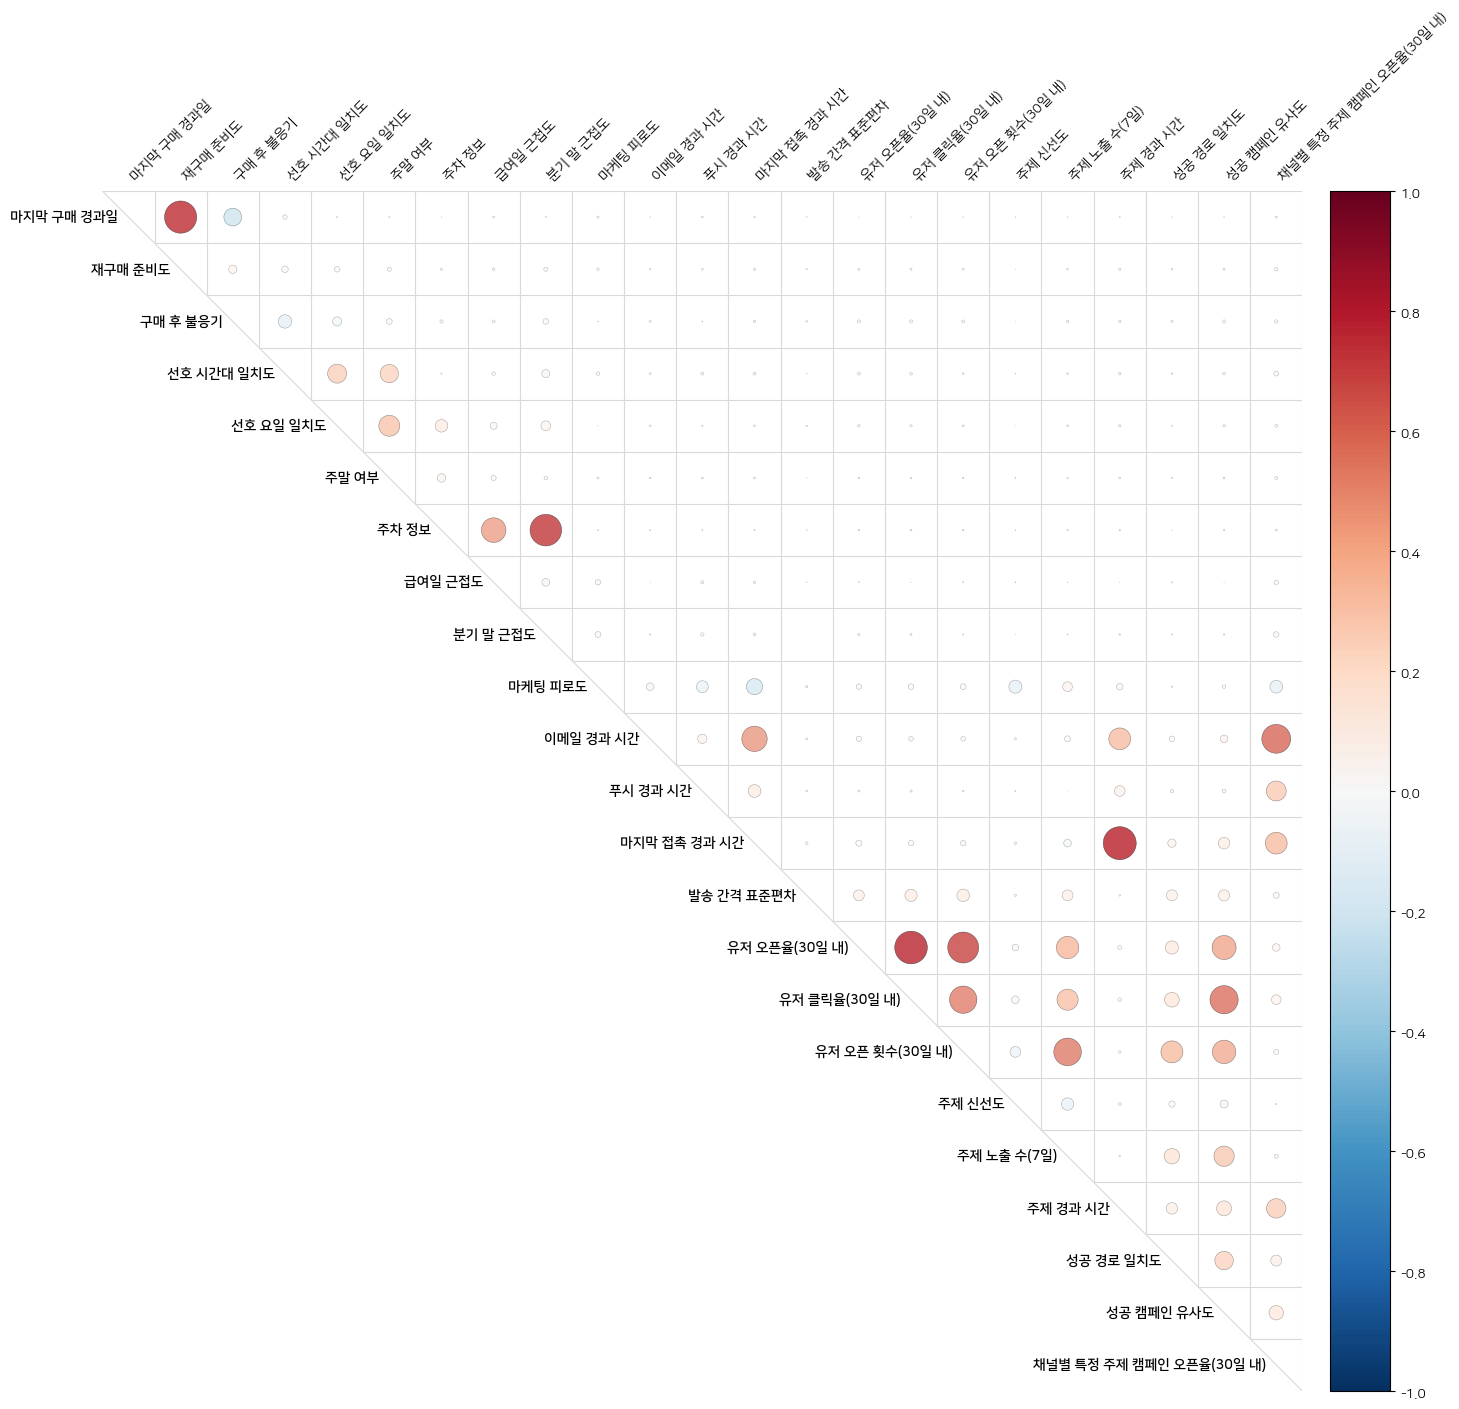

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1. 데이터 로드 (Data Loading)
# -------------------------------------------------------
print("Loading Feature Sets...")

try:
    # Target 변수(is_purchased) 확보를 위해 v0도 로드 권장
    df_v0 = pd.read_parquet("featured_v0.parquet") 
    df_v1 = pd.read_parquet("featured_v1.parquet")
    df_v2 = pd.read_parquet("featured_v2.parquet")
    df_v3 = pd.read_parquet("featured_v3.parquet")
    df_v4 = pd.read_parquet("featured_v4.parquet")
    
    # 데이터프레임 리스트 (검색용)
    dfs = [df_v0, df_v1, df_v2, df_v3, df_v4]
    
except FileNotFoundError as e:
    print("오류: 파케이 파일을 찾을 수 없습니다.")
    raise e

# -------------------------------------------------------
# 2. 분석할 변수 리스트 정의 (요청하신 리스트 적용)
# -------------------------------------------------------
target_col = "is_purchased" # 타겟 변수는 고정

# 요청하신 Feature 리스트
feature_cols = [
    "feat_hour_shift", "feat_dow_shift", "feat_rtb_hazard", "cal_is_weekend", 
    "days_since_last_purchase", "cal_week_of_month", "feat_payday_bump", 
    "feat_eoq_bump", "ctx_tc_open_rate_30d",#"ctx_camp_open_rate_30d",  
    "feat_fatigue", "feat_postbuy_refrac", "u_open_rate_30d", 
    "u_click_rate_30d", "feat_last_any_hours", "feat_topic_novelty", 
    "feat_like_last_success", #"u_buy_rate_30d", #"ctx_tc_buy_rate_30d", 
    "topic_N7", "feat_last_mobile_push_hours", "topic_t_since_hours", 
    "u_open_cnt_30d", "feat_path_align", "feat_last_email_hours", 
    "u_cadence_std_30d", #"ctx_camp_buy_rate_30d", #"u_buy_cnt_30d"
]

# -------------------------------------------------------
# 3. 데이터 자동 병합 (Auto Merging)
# -------------------------------------------------------
print("Merging selected features...")

# 1) Base DataFrame 생성 (Target 포함)
# Target이 v0에 있다고 가정, 없으면 모든 df 검색
if target_col in df_v0.columns:
    final_data = df_v0[[target_col]].copy()
else:
    # v0에 없으면 다른 곳에서 찾기
    for df in dfs:
        if target_col in df.columns:
            final_data = df[[target_col]].copy()
            break

# 2) Feature List 순회하며 해당 변수가 있는 DF에서 가져오기
found_cols = []
missing_cols = []

for col in feature_cols:
    col_added = False
    for df in dfs:
        if col in df.columns:
            # 이미 병합된 컬럼이 아닌 경우에만 추가
            if col not in final_data.columns:
                final_data[col] = df[col]
            col_added = True
            found_cols.append(col)
            break
    
    if not col_added:
        missing_cols.append(col)

print(f"Merge Complete. Shape: {final_data.shape}")
if missing_cols:
    print(f"⚠️ 경고: 다음 변수들은 데이터에서 찾을 수 없어 제외되었습니다: \n{missing_cols}")

# -------------------------------------------------------
# 4. 결측치 처리 (Imputation)
# -------------------------------------------------------
# (1) 주제 신선도 (Novelty) -> 평균 보간
if "feat_topic_novelty" in final_data.columns:
    final_data["feat_topic_novelty"] = final_data["feat_topic_novelty"].fillna(final_data["feat_topic_novelty"].mean())

# (2) 시간/요일 시프트 -> 중앙값(Neutral) 보간
for col in ["feat_hour_shift", "feat_dow_shift"]:
    if col in final_data.columns:
        final_data[col] = final_data[col].fillna(final_data[col].median())

# (3) 나머지 수치형 변수 -> 0으로 채우기 (Rate, Count 등)
final_data = final_data.fillna(0.0)

# 최종 분석용 컬럼 리스트 (Target + 찾은 변수들)
analysis_cols = [target_col] + [c for c in feature_cols if c in final_data.columns]

kor_col_map = {
    "is_purchased": "구매 여부(Target)",
    
    # [기존 매핑]
    "days_since_last_purchase": "마지막 구매 경과일",
    "feat_rtb_hazard": "재구매 준비도",
    "feat_postbuy_refrac": "구매 후 불응기",
    "feat_hour_shift": "선호 시간대 일치도",
    "feat_dow_shift": "선호 요일 일치도",
    "cal_is_weekend": "주말 여부",
    "cal_week_of_month": "주차 정보",
    "feat_payday_bump": "급여일 근접도",
    "feat_eoq_bump": "분기 말 근접도",
    "feat_fatigue": "마케팅 피로도",
    "feat_last_email_hours": "이메일 경과 시간",
    "feat_last_mobile_push_hours": "푸시 경과 시간",
    "feat_last_any_hours": "마지막 접촉 경과 시간",
    "u_cadence_std_30d": "발송 간격 표준편차",
    "u_open_rate_30d": "유저 오픈율(30일 내)",
    "u_click_rate_30d": "유저 클릭율(30일 내)",
    "u_open_cnt_30d": "유저 오픈 횟수(30일 내)",
    "feat_topic_novelty": "주제 신선도",
    "topic_N7": "주제 노출 수(7일)",
    "topic_t_since_hours": "주제 경과 시간",
    "feat_path_align": "성공 경로 일치도",
    "feat_like_last_success": "성공 캠페인 유사도",
    "ctx_tc_open_rate_30d": "채널별 특정 주제 캠페인 오픈율(30일 내)",

    # [추가된 베이스라인 매핑 - '[베이스라인]' 태그 제거됨]
    "avg_campaign_duration": "캠페인 지속 시간(평균)",
    "avg_time_since_complaint": "불만 접수 경과 시간(평균)",
    "avg_time_since_first_purchase": "가입 기간(첫 구매 경과)",
    "avg_time_since_last_click": "마지막 클릭 경과 시간(평균)",
    "avg_time_since_last_open": "마지막 오픈 경과 시간(평균)",
    "avg_time_since_unsubscribe": "구독 취소 경과 시간(평균)",
    "is_holiday": "공휴일 여부",
    "total_campaigns": "총 캠페인 수",
    "total_messages": "총 메시지 수신 수",
    "total_purchases": "총 구매 횟수",
    "platform.": "메시지 수신: 기타",
    "platform.desktop": "메시지 수신: 데스크탑",
    "platform.phablet": "메시지 수신: 패블릿",
    "platform.smartphone": "메시지 수신: 스마트폰",
    "platform.tablet": "메시지 수신: 태블릿",
    "channel_email": "발송 채널: 이메일",
    "channel_mobile_push": "발송 채널: 모바일 푸시",
    "channel_web_push": "발송 채널: 웹 푸시",
    "email_provider_gmail.com": "이메일 계정: 지메일",
    "email_provider_mail.ru": "이메일 계정: Mail.ru",
    "email_provider_other": "이메일 계정: 기타",
    "camp_campaign_typebulk": "채널 캠페인 유형: 전체 유저 발송",
    "camp_campaign_typetransactional": "채널 캠페인 유형: 기타 거래 발송",
    "camp_campaign_typetrigger": "채널 캠페인 유형: 특정 유저행동 발송",
    "camp_channelemail": "캠페인 채널: 이메일",
    "camp_channelmobile_push": "캠페인 채널: 모바일 푸시",
    "camp_channelmultichannel": "캠페인 채널: 멀티채널",
    "camp_channelsms": "캠페인 채널: SMS",
    "camp_topicevent": "캠페인 주제: 이벤트",
    "camp_topichappy.birthday": "캠페인 주제: 생일 축하",
    "camp_topicleave.review": "캠페인 주제: 리뷰 요청",
    "camp_topicoffer.after.purchase": "캠페인 주제: 연관 상품 추천",
    "camp_topicother": "캠페인 주제: 기타",
    "camp_topicsale.out": "캠페인 주제: 할인 정보",
    "message_type_bulk": "채널 메세지 유형: 전체 유저 발송",
    "message_type_transactional": "채널 메세지 유형: 기타 거래 발송",
    "message_type_trigger": "채널 메세지 유형: 특정 유저행동 발송",
    "prev_is_clicked": "메시지 클릭 여부",
    "prev_is_complained": "메시지 불만 접수 여부",
    "prev_is_opened": "메시지 오픈 여부",
    "prev_is_unsubscribed": "메시지 구독 취소 여부",
}

# 실제 데이터에 있는 컬럼만 매핑 적용
current_cols = final_data.columns.tolist()
rename_dict = {k: v for k, v in kor_col_map.items() if k in current_cols}

# 컬럼명 변경 적용
final_data.rename(columns=rename_dict, inplace=True)

# 분석용 리스트도 한글로 업데이트
analysis_cols = list(rename_dict.values())

print("Renaming Complete.")

# -------------------------------------------------------
# [분석 2] 상관관계 "원형" 히트맵 (corrplot 스타일)
# -------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'NanumSquare'  # 한글 폰트

# ================================
# Corrplot (개선된 시각화 버전)
# ================================
def corrplot_triangle_moveYlabels_to_diag(
    corr, labels=None,
    triangle="upper",          # "upper" or "lower"
    figsize=(14, 12),
    cmap="RdBu_r", vmin=-1, vmax=1,
    max_marker_area=900,
    grid_color="#d9d9d9",
    grid_lw=0.8,
    xrot=45,
    tick_fontsize=10,
    x_on_top=True,
    diag_label_fontsize=10,
    diag_label_dx=0.35,        # 대각선 라벨을 왼쪽으로 얼마나 뺄지
    savepath=None, dpi=300
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.collections import LineCollection

    corr = corr.copy()
    n = corr.shape[0]
    if labels is None:
        labels = list(corr.columns)

    # =========================
    # 1) 삼각형에 찍을 점 만들기
    # =========================
    xs, ys, cs, ss = [], [], [], []
    for i in range(n):
        for j in range(n):
            cond = (i < j) if triangle == "upper" else (i > j)
            if cond:
                val = corr.iat[i, j]
                xs.append(j + 0.5)                  # cell center
                ys.append(i + 0.5)
                cs.append(val)
                ss.append((abs(val) ** 1.25) * max_marker_area)

    fig, ax = plt.subplots(figsize=figsize)
    cs_arr = np.asarray(cs)
    alphas = 0.35 + 0.65 * np.abs(cs_arr)   # 0일 때도 0.35는 유지

    sc = ax.scatter(
        xs, ys,
        c=cs_arr,
        s=ss,
        cmap=cmap, vmin=vmin, vmax=vmax,     # ✅ 선형 유지(왜곡 없음)
        alpha=alphas,                        # ✅ 약한 상관도 보이게
        edgecolors="#333333",                # ✅ 흰색에 묻히지 않게 테두리
        linewidths=0.35
    )
    '''
    

    sc = ax.scatter(
        xs, ys,
        c=cs, s=ss,
        cmap=cmap, vmin=vmin, vmax=vmax,
        edgecolors="none", alpha=0.95
    )
'''
    # =========================
    # 2) 축 범위/방향 + 정사각
    # =========================
    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.invert_yaxis()
    ax.set_aspect("equal")

    # =========================
    # 3) X축 라벨은 유지
    # =========================
    ax.set_xticks(np.arange(n) + 0.5)
    ax.set_xticklabels(labels, rotation=xrot, ha="left", va="bottom", fontsize=tick_fontsize)
    if x_on_top:
        ax.xaxis.tick_top()
    ax.tick_params(axis="x", length=0, pad=6)

    # ✅ Y축 tick/라벨은 "표시하지 않음" (대각선으로 옮길거라)
    ax.set_yticks(np.arange(n) + 0.5)
    ax.set_yticklabels([""] * n)
    ax.tick_params(axis="y", length=0, pad=0)

    # =========================
    # 4) 테두리 제거
    # =========================
    for s in ax.spines.values():
        s.set_visible(False)

    # =========================
    # 5) 삼각형 영역에만 격자
    # =========================
    segs = []

# (A) 기존 네모 격자: 삼각형 영역 내부만
    for k in range(n + 1):
        if triangle == "upper":
        # vertical: x=k, y in [0, k]
            segs.append([(k, 0), (k, k)])
        else:
        # vertical: x=k, y in [k, n]
            segs.append([(k, k), (k, n)])

    for k in range(n + 1):
        if triangle == "upper":
        # horizontal: y=k, x in [k, n]
            segs.append([(k, k), (n, k)])
        else:
        # horizontal: y=k, x in [0, k]
            segs.append([(0, k), (k, k)])

# (B) ✅ 대각선 "한 줄" 추가: 셀 경계 기준의 계단 라인
# triangle="upper" 일 때: (0,0)->(1,1)->... 경계가 더 또렷해짐
    for i in range(n + 1):
    # 대각선 경계선 자체를 한 번 더 덧그림 (강조)
        segs.append([(i, i), (i + 1 if i < n else i, i + 1 if i < n else i)])

    ax.add_collection(LineCollection(segs, colors=grid_color, linewidths=grid_lw))

    # =========================
    # 6) ✅ Y축 라벨들을 "대각선"으로 이동 (글자는 수평!)
    #    - 각 i에 대해 (x=i, y=i) 대각선 셀의 왼쪽에 붙임
    # =========================
    for i, lab in enumerate(labels):
        ax.text(
            i + 0.5 - diag_label_dx,   # 대각선 셀 중심에서 왼쪽으로 살짝 이동
            i + 0.5,
            lab,
            ha="right",
            va="center",
            rotation=0,                # ✅ 글자 회전 없음
            fontsize=diag_label_fontsize,
            fontweight="bold",
            color="black",
            clip_on=False
        )

    # =========================
    # 7) 컬러바
    # =========================
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_ticks(np.linspace(-1, 1, 11))

    # =========================
    # 8) 여백 최소화
    # =========================
    plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

    if savepath:
        plt.savefig(savepath, dpi=dpi, bbox_inches="tight", pad_inches=0)
    plt.show()

target_kor = rename_dict.get("is_purchased", "구매 여부(Target)")
plot_cols = [c for c in analysis_cols if c != target_kor]


# === 사용 ===
corr_matrix = final_data[plot_cols].corr(method="pearson")

corrplot_triangle_moveYlabels_to_diag(
    corr_matrix,
    labels=plot_cols,
    triangle="upper",
    figsize=(14, 12),
    cmap="RdBu_r",
    max_marker_area=800,
    xrot=45,
    tick_fontsize=10,
    diag_label_fontsize=10,
    diag_label_dx=0.2,
    savepath="corrplot_upper_moveY_to_diag.png"
)


Saved: radar_chart_all_models_no_baseline_legend_bottom.png


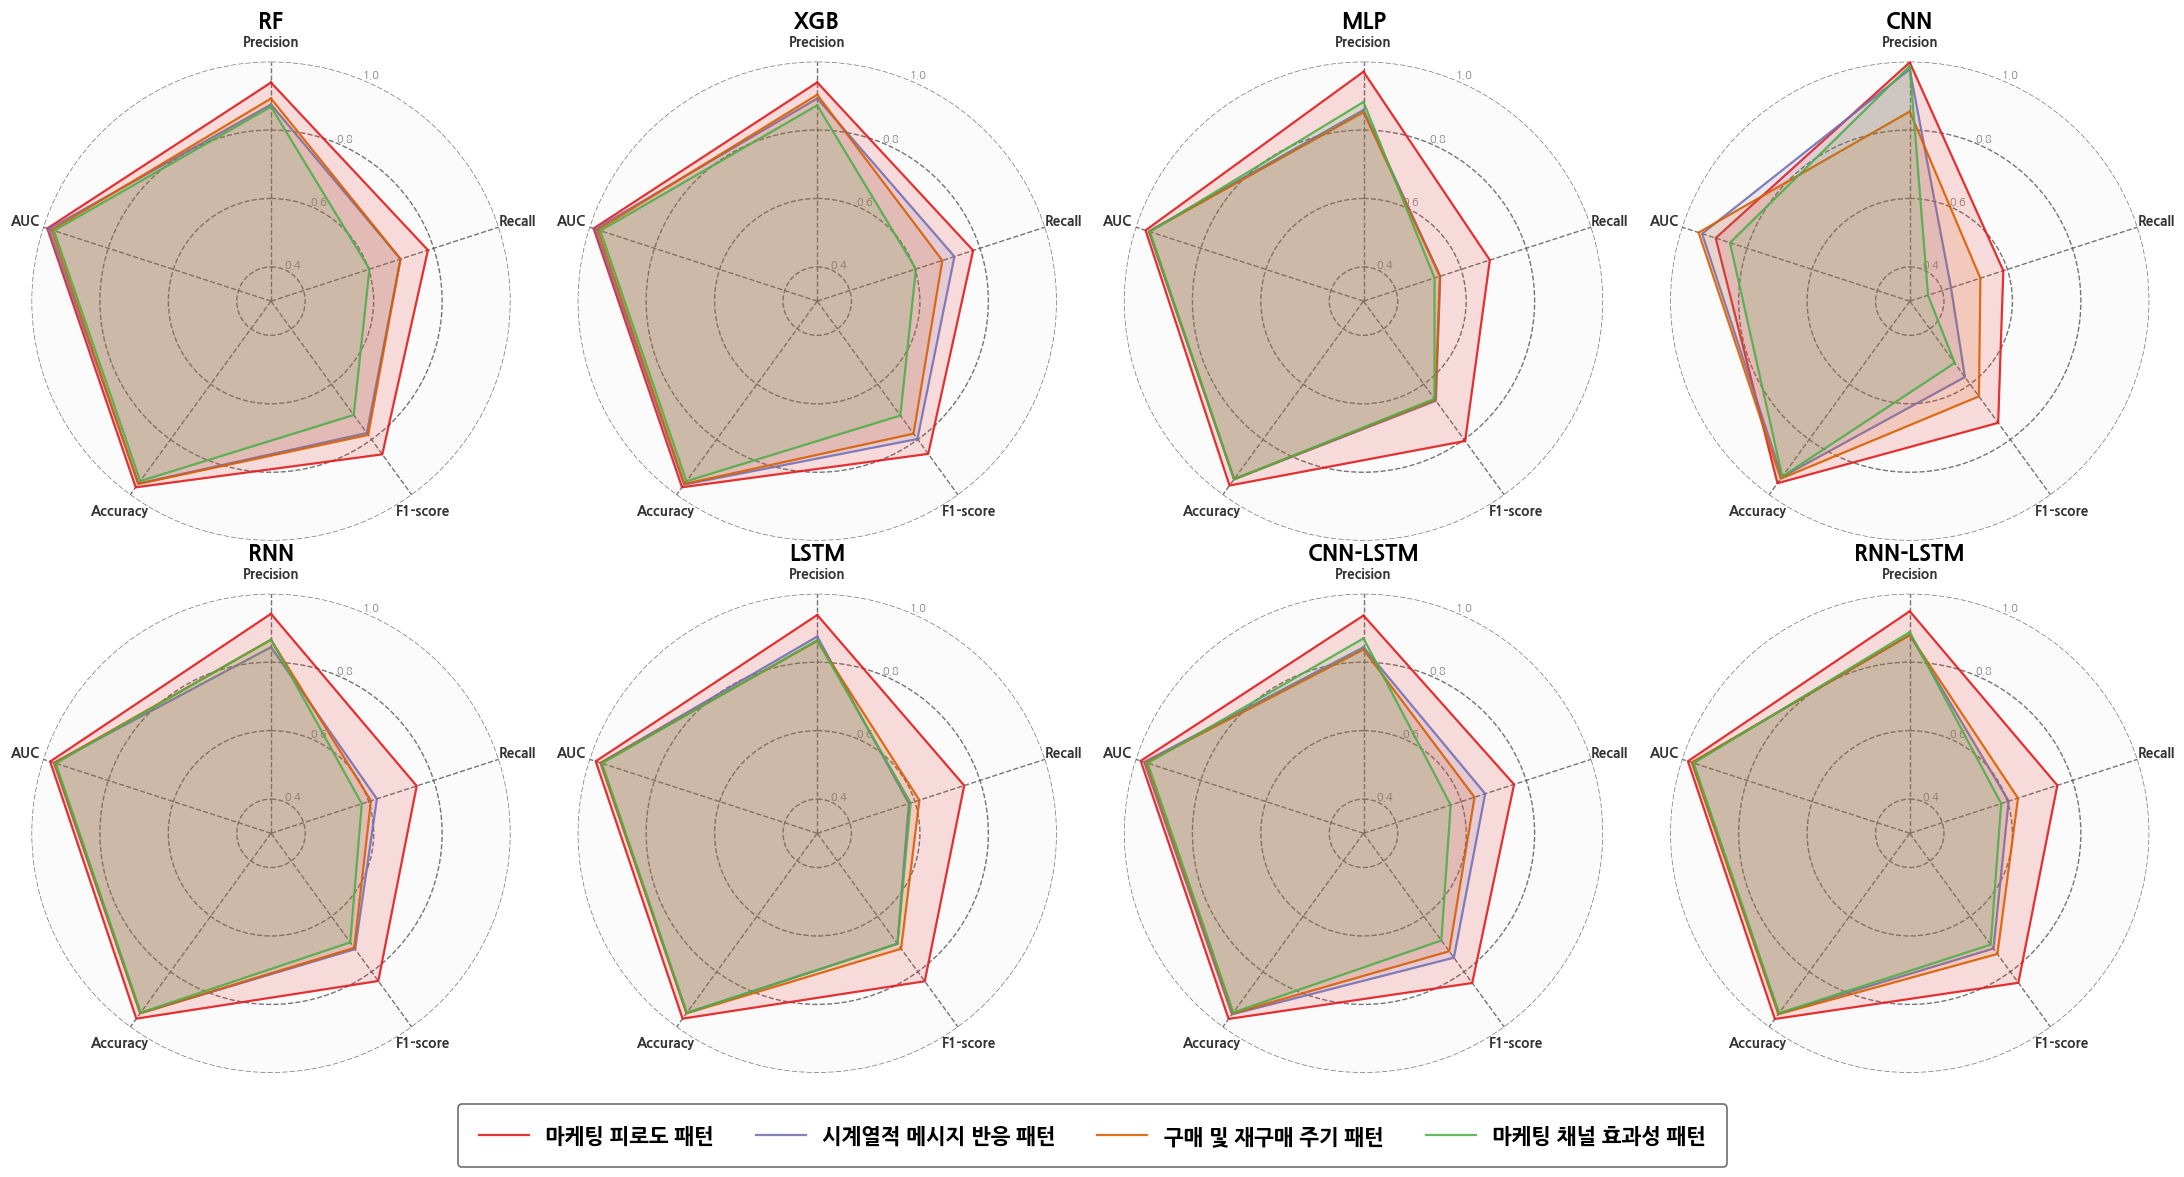

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import pi, sin
import matplotlib.font_manager as fm
import platform

# -----------------------------
# Font setup (Korean)
# -----------------------------
system_name = platform.system()
if system_name == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif system_name == 'Windows':
    font_list = [f.name for f in fm.fontManager.ttflist]
    if 'NanumSquare' in font_list:
        plt.rcParams['font.family'] = 'NanumSquare'
    else:
        plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# -------------------------------------------------------
# 1) Data (YOUR TABLE VALUES)
# Each list: [Accuracy, Precision, Recall, F1-score, AUC]
# -------------------------------------------------------
data_map = {
    "RF": [
        [0.9483, 0.8564, 0.5928, 0.7007, 0.9641],  # V0
        [0.9606, 0.8922, 0.6980, 0.7833, 0.9737],  # V1
        [0.9590, 0.8746, 0.6980, 0.7764, 0.9826],  # V2
        [0.9725, 0.9388, 0.7823, 0.8534, 0.9873],  # V3
        [0.9501, 0.8681, 0.6026, 0.7114, 0.9671],  # V4
    ],
    "XGB": [
        [0.9479, 0.8401, 0.6046, 0.7032, 0.9639],
        [0.9603, 0.9033, 0.6843, 0.7787, 0.9743],
        [0.9627, 0.8924, 0.7216, 0.7980, 0.9817],
        [0.9723, 0.9393, 0.7790, 0.8517, 0.9871],
        [0.9505, 0.8724, 0.6032, 0.7132, 0.9665],
    ],
    "RNN-LSTM": [
        [0.9486, 0.8710, 0.5830, 0.6985, 0.9631],
        [0.9536, 0.8792, 0.6326, 0.7358, 0.9697],
        [0.9511, 0.8799, 0.6039, 0.7162, 0.9681],
        [0.9707, 0.9489, 0.7535, 0.8400, 0.9816],
        [0.9497, 0.8881, 0.5810, 0.7024, 0.9638],
    ],
    "CNN-LSTM": [
        [0.9468, 0.8499, 0.5810, 0.6902, 0.9653],
        [0.9507, 0.8370, 0.6412, 0.7261, 0.9691],
        [0.9540, 0.8436, 0.6739, 0.7493, 0.9740],
        [0.9705, 0.9365, 0.7627, 0.8407, 0.9846],
        [0.9472, 0.8698, 0.5679, 0.6872, 0.9632],
    ],
    "LSTM": [
        [0.9463, 0.8695, 0.5575, 0.6794, 0.9601],
        [0.9505, 0.8622, 0.6137, 0.7170, 0.9651],
        [0.9488, 0.8751, 0.5816, 0.6988, 0.9661],
        [0.9695, 0.9380, 0.7516, 0.8345, 0.9807],
        [0.9484, 0.8642, 0.5869, 0.6991, 0.9615],
    ],
    "RNN": [
        [0.9463, 0.8659, 0.5614, 0.6812, 0.9605],
        [0.9503, 0.8657, 0.6071, 0.7137, 0.9654],
        [0.9499, 0.8439, 0.6254, 0.7184, 0.9673],
        [0.9695, 0.9415, 0.7477, 0.8335, 0.9786],
        [0.9479, 0.8660, 0.5790, 0.6940, 0.9613],
    ],
    "MLP": [
        [0.9421, 0.8727, 0.5065, 0.6410, 0.9555],
        [0.9431, 0.8520, 0.5346, 0.6570, 0.9582],
        [0.9437, 0.8586, 0.5359, 0.6600, 0.9601],
        [0.9660, 0.9705, 0.6882, 0.8053, 0.9696],
        [0.9437, 0.8820, 0.5183, 0.6529, 0.9564],
    ],
    "CNN": [
        [0.9399, 0.8764, 0.4778, 0.6184, 0.9397],
        [0.9417, 0.8542, 0.5170, 0.6441, 0.9487],
        [0.9355, 0.9776, 0.4268, 0.5743, 0.9381],
        [0.9577, 0.9977, 0.5875, 0.7396, 0.8963],
        [0.9338, 0.9873, 0.3562, 0.5235, 0.8524],
    ],
}

# -----------------------------
# 2) Build DataFrame
# -----------------------------
versions = ["V0", "V1", "V2", "V3", "V4"]
metrics = ["Precision", "Recall", "F1-score", "Accuracy", "AUC"]

rows = []
for model, vv in data_map.items():
    for i, ver in enumerate(versions):
        acc, prec, rec, f1, auc = vv[i]  # 원본 순서 [Acc, Prec, Rec, F1, AUC]
        rows.append({
            "Model": model,
            "Version": ver,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-score": f1,
            "AUC": auc,
        })
df = pd.DataFrame(rows)

# -----------------------------
# 3) Radar area (optional)
# -----------------------------
def compute_radar_area(values):
    values = np.array(values, dtype=float)
    N = len(values)
    delta = 2 * pi / N
    return 0.5 * sin(delta) * np.sum(values * np.roll(values, -1))

df["RadarArea"] = df.apply(lambda r: compute_radar_area(r[metrics].values), axis=1)

# -----------------------------
# 4) Radar chart settings
# -----------------------------
version_labels = {
    "V1": "구매 및 재구매 주기 패턴",
    "V2": "시계열적 메시지 반응 패턴",
    "V3": "마케팅 피로도 패턴",
    "V4": "마케팅 채널 효과성 패턴",
}

colors = {
    "V0": "#1b9e77",
    "V1": "#d95f02",
    "V2": "#7570b3",
    "V3": "#e41a1c",  # 강조
    "V4": "#4daf4a",
}

# ✅ 베이스라인 제외 + legend 순서 요청대로
plot_versions = ["V3", "V2", "V1", "V4"]

categories = metrics
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(
    nrows=2, ncols=4,
    figsize=(22, 12),
    subplot_kw=dict(polar=True)
)
axes = axes.flatten()

model_order = ["RF", "XGB", "MLP", "CNN", "RNN", "LSTM", "CNN-LSTM", "RNN-LSTM"]

for i, model_name in enumerate(model_order):
    ax = axes[i]
    model_data = df[df["Model"] == model_name]

    # ✅ 위에서 시작 + 시계방향
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    for ver in plot_versions:
        vals = model_data[model_data["Version"] == ver][categories].values.flatten().tolist()
        vals += vals[:1]

        ax.plot(
            angles, vals,
            linewidth=1.6,
            linestyle="-",
            marker=None,
            color=colors[ver],
            alpha=0.88,
            label=version_labels[ver] if i == 0 else ""  # 첫 번째 subplot에서만 label 수집
        )

        ax.fill(
            angles, vals,
            color=colors[ver],
            alpha=0.14,
            zorder=2
        )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10, fontweight="bold", color="#333333")

    ax.set_title(model_name, size=16, weight="bold", position=(0.5, 1.12))

    ax.set_ylim(0.3, 1.0)
    ax.set_yticks([0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.4", "0.6", "0.8", "1.0"], color="grey", size=8)

    ax.grid(color="#666666", linestyle="--", linewidth=1, alpha=0.9)
    ax.spines["polar"].set_visible(False)

    ax.set_facecolor("#fbfbfb")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("#888888")
        spine.set_linewidth(1.2)
    ax.spines["polar"].set_visible(False)

# 혹시 axes 남으면 숨김(안전)
for j in range(len(model_order), len(axes)):
    axes[j].axis("off")

# ✅ legend가 아래로 갈 자리 확보
plt.tight_layout(rect=[0.0, 0.08, 1.0, 1.0])

# ✅ figure 하단 legend (글씨 +2, bold)
handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=4,                 # 4개면 2열이 깔끔 (원하면 4로 바꾸면 한 줄)
    frameon=True,
    prop={'size':15,"weight": "bold"},
    borderpad=1.0,
    handlelength=2.4,
    labelspacing=1.0,
    handletextpad=0.8
)

frame = leg.get_frame()
frame.set_facecolor("white")
frame.set_edgecolor("#666666")
frame.set_linewidth(1.2)
frame.set_alpha(0.95)

out_path = "radar_chart_all_models_no_baseline_legend_bottom.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()
